# HW 4: Portfafolio eficiente

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf

from scipy.optimize import minimize

## Assets qualitative research

### Eli Lilly and Company (LLY)

Lilly es una compañía fundada en 1876 en Indianapolis dedicada al desarrollo, manofactura y venta de medicamentos para la salud principalmente. Los productos de la firma consisten atienden diferentes tipos de diagnosticos tales como:

- Diabetes
- Inmunologicos
- neurodegenerativos
- etc.

### NVIDIA Corp (NVDA)

NVIDIA Corp. es una compañía dedicada al diseño y manofactura de procesadores graficos para computadoras, conjuntos de chips y algunos softwares. Opera a través de los siguientes segmentos: Unidad de procesamiento gráfico (GPU) y Computación y redes.

### Microsoft Corp (MSFT)

Microsoft Corp. se dedica al desarrollo y soporte de software, servicios, dispositivos y soluciones. Opera a través de los siguientes segmentos: Productividad y Procesos de Negocio, Nube Inteligente y Computación Personal. 

### KXI - ETF (KXI)

KXI sigue un índice ponderado por capitalización de mercado de empresas globales de bienes de consumo básico, extraído de 1200 acciones globales seleccionadas por S&P.

## Assets quantitative research

In [3]:
tickers = ["LLY", "NVDA", "MSFT", "KXI"]

start_date = "2018-01-01"
end_date = "2026-02-26"

In [4]:
prices = yf.download(tickers=tickers, start=start_date, end=end_date)["Close"]
prices.head(4)

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  4 of 4 completed


Ticker,KXI,LLY,MSFT,NVDA
Date,,,,
2018-01-02,43.383411,75.026726,78.870346,4.928534
2018-01-03,43.387520,75.434311,79.237396,5.252898
2018-01-04,43.482101,75.770943,79.934814,5.280590
2018-01-05,43.761726,76.701271,80.925842,5.325338


### Returns and Vol

Comenzaremos con el calculo del rendimiento promedio de los activos así como las metricas de riesgo individual y la matriz de covarianza para posteriormente poder calcular las medidas de riesgo en conjunto como un portafolio

Calculo del rendimiento aritmetico de los precios de forma diaria


$$
R_i = \frac{S_t}{S_{t-1}} - 1
$$

In [5]:
returns = prices.pct_change().dropna()
returns.head(3)

Ticker,KXI,LLY,MSFT,NVDA
Date,,,,
2018-01-03,0.000095,0.005433,0.004654,0.065813
2018-01-04,0.002180,0.004463,0.008802,0.005272
2018-01-05,0.006431,0.012278,0.012398,0.008474


Rendimiento promedio diario de los activos de forma individual

$$
\hat{\mu} = \frac{1}{n} \sum_{i = 1}^n R_i
$$


In [6]:
assets_mean_return = returns.mean()
assets_mean_return

Ticker
KXI     0.000296
LLY     0.001477
MSFT    0.000956
NVDA    0.002315
dtype: float64

Rendimiento anualizado porcentual


$$
\hat{\mu}_{anual-port} = \hat{\mu} \times 100 \times 252
$$

In [7]:
assets_mean_return * 100 * 252

Ticker
KXI      7.449144
LLY     37.226818
MSFT    24.098605
NVDA    58.345631
dtype: float64

Calculo de la volatilidad invidual de cada activo de forma diaria

$$
\hat{\sigma} = \sqrt{ \frac{1}{n} \sum_{i=1}^n(R_i - \hat{\mu})^2}
$$

In [8]:
assets_vol_return = returns.std()
assets_vol_return

Ticker
KXI     0.009097
LLY     0.019964
MSFT    0.018002
NVDA    0.032143
dtype: float64

Escalamos las unidades para poder apreciarlas en un ventana temporal anual y porcentual

$$
\hat{\sigma}_{anual-port} = \hat{\sigma} \times 100 \times \sqrt{252}
$$

In [9]:
assets_vol_return * 100 * np.sqrt(252)

Ticker
KXI     14.440990
LLY     31.691666
MSFT    28.576848
NVDA    51.024877
dtype: float64

Por ultimo calculamos la matriz de covarianza de los activos

$$
\hat{\sigma}_{i,j} = \operatorname{Cov}(R_i,R_j) = \frac{1}{n} \sum_{k=1}^n (R_{ik} - \hat{\mu}_i)(R_{jk} - \hat{\mu}_j) 
$$

La cual queda representada por

$$
\Sigma \;=\;
\begin{pmatrix}
\sigma_{11} & \sigma_{12} & \cdots & \sigma_{1n}\\
\sigma_{21} & \sigma_{22} & \cdots & \sigma_{2n}\\
\vdots      & \vdots      & \ddots & \vdots\\
\sigma_{n1} & \sigma_{n2} & \cdots & \sigma_{nn}
\end{pmatrix},
$$

In [10]:
assets_cov = returns.cov()
assets_cov

Ticker,KXI,LLY,MSFT,NVDA
Ticker,,,,
KXI,0.000083,0.000070,0.000087,0.000097
LLY,0.000070,0.000399,0.000112,0.000145
MSFT,0.000087,0.000112,0.000324,0.000377
NVDA,0.000097,0.000145,0.000377,0.001033


### Efficient portfolio: min volatility

Con la matriz de covarianza podemos optimizar los pesos $w$ de un portafolio con el objetivo de obtener un portafolio de minima varianza. Para ello se plantea un problema de optimización.

$$
min \space \sigma^2 = \text{w}^T \Sigma \text{w}
$$

s.a.


$$
\sum_{i=1}^n w_i = 1; \space \space w_i > 0
$$


In [11]:
n_assets = len(returns.columns)

# Definimos la funcion objetivo
def variance(w: pd.Series) -> float:
    return w.T @ assets_cov @ w

# Restricciones
def sum_weight(w: pd.Series) -> 0:
    return sum(w) - 1

def min_return(w: pd.Series):
    return sum(w @ (assets_mean_return * 100 * 252)) - 12

# condiciones iniciales
initial_weight = np.ones(n_assets) / n_assets

# Bounds
bounds = [(0, 1)] * n_assets

#tol
tol = 1e-50

result = minimize(
    fun=variance, 
    x0=initial_weight,
    bounds=bounds,
    constraints={"fun" : sum_weight, "type" : "eq"},
    tol = tol)

portfolio_weight_min_var = result.x
result

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 8.226060239188394e-05
           x: [ 9.620e-01  3.803e-02  3.848e-29  4.633e-18]
         nit: 23
         jac: [ 1.645e-04  1.645e-04  1.756e-04  1.979e-04]
        nfev: 126
        njev: 22
 multipliers: [ 1.645e-04]

In [12]:
dict(zip(returns.columns, result.x))

{'KXI': np.float64(0.9619736153263881),
 'LLY': np.float64(0.0380263846736118),
 'MSFT': np.float64(3.847983632462368e-29),
 'NVDA': np.float64(4.6325659656545816e-18)}

Con los pesos calculados, ahora podemos determinar las medidas de riesgo y rendimiento del portafolio.

Primero calcularemos la medida de rendimiento la cual esta dada por:

$$
\hat{\mu}_{\Pi} = \mathbf{\text{w}} \cdot \mathbf{\hat{\mu}}
$$

In [13]:
portfolio_min_var_mean_return = portfolio_weight_min_var @ assets_mean_return
portfolio_min_var_mean_return

np.float64(0.0003405349797613771)

Escalamos la medida a su forma anual y porcentual

In [14]:
portfolio_min_var_mean_return * 100 * 252

np.float64(8.581481489986702)

Finalizamos con la medida de riesgo del portafolio medida como la volatilidad dada por

$$
\hat{\sigma}_{\Pi} = \sqrt{\mathbf{\text{w}}^T \cdot \Sigma \cdot \mathbf{\text{w}}}
$$

In [15]:
portfolio_min_var_vol_return = np.sqrt(portfolio_weight_min_var.T @ assets_cov @ portfolio_weight_min_var)
portfolio_min_var_vol_return

np.float64(0.009069763083558684)

De la misma forma escalamos esta medida a una escala y porcentual

In [16]:
portfolio_min_var_vol_return * 100 * np.sqrt(252)

np.float64(14.397802541622369)

### Efficient portfolio: max sharpe


Continuamos con el portafolio de max sharpe. Pare ello planteamos el problema de optimización

$$
min \space -sharpe = - \frac{\hat{\mu}_{\Pi} - r_f}{\hat{\sigma}_{\Pi}}
$$

s.a.

$$
\sum_{i = 1} ^n w_i = 1; \space \space w_i > 0
$$

se toma el inverso aditivo del sharpe dado que el metodo de optimización solo admite funciones convexas y por tanto es necesario ajustar el problema a uno de minimizacion.


Partimos de plantear el problema de optimizacion y definir nuestra tasa libre de riesgo.

In [17]:
# inputs 3.78 
rf = 0.03 / 252

# funcion objetivo
def max_sharpe(w:pd.Series) -> float:
    mean_return = w @ assets_mean_return
    vol_return = np.sqrt(w.T @ assets_cov @ w)
    return (-1)*((mean_return - rf) / vol_return)

# restricciones
def sum_weight(w : pd.Series):
    return sum(w) - 1

# condiciones iniciales
initial_weight = np.ones(n_assets) / n_assets

#Bounds
bounds = [(0,1)] * n_assets

#tol
tol = 1e-50

result_max = minimize(
    fun=max_sharpe,
    x0=initial_weight,
    constraints={"fun": sum_weight, "type": "eq"},
    bounds=bounds,
    tol = tol
)

portfolio_weight_max_sharpe = result_max.x
result_max

     message: Iteration limit reached
     success: False
      status: 9
         fun: -0.08707839905819348
           x: [ 6.748e-17  6.152e-01  1.590e-17  3.848e-01]
         nit: 100
         jac: [ 3.454e-03 -6.168e-03  5.568e-04 -6.168e-03]
        nfev: 1375
        njev: 99
 multipliers: [-6.168e-03]

In [18]:
dict(zip(returns.columns, portfolio_weight_max_sharpe))

{'KXI': np.float64(6.748199960771856e-17),
 'LLY': np.float64(0.615241999798007),
 'MSFT': np.float64(1.589640866566217e-17),
 'NVDA': np.float64(0.38475800020199313)}

continuamos calculando las medidas de riesgo y rendimiento del portafolio con los pesos del max_sharpe

Calculamos la medida de rendimiento segun la definición dada previamente.

In [19]:
portfolio_max_sharpe_mean_return = portfolio_weight_max_sharpe @ assets_mean_return
portfolio_max_sharpe_mean_return

np.float64(0.001799700423467192)

Escalamos la ventana de tiempo a una anual y en porcentaje

In [20]:
portfolio_max_sharpe_mean_return * 100 * 252

np.float64(45.35245067137324)

Finalmente calculamos la medida de riesgo del portafolio dada la definición previa.

In [21]:
portfolio_max_sharpe_vol_return = np.sqrt(portfolio_weight_max_sharpe.T @ assets_cov @ portfolio_weight_max_sharpe)
portfolio_max_sharpe_vol_return

np.float64(0.019300455940817335)

También escalamos

In [22]:
portfolio_max_sharpe_vol_return * 100 * np.sqrt(252)

np.float64(30.638523965737097)

### Portfolio same weight

Ahora calcularemos las medidas de riesgo y rendimiento para un portafolio igualmente ponderado

Empezamos por el rendimiento

In [23]:
portfolio_weight_same_weight = np.ones(n_assets) / n_assets

portfolio_same_weight_mean_return = portfolio_weight_same_weight @ assets_mean_return
portfolio_same_weight_mean_return

np.float64(0.0012611130824302405)

Escalamos

In [24]:
portfolio_same_weight_mean_return * 100 * 252

np.float64(31.78004967724206)

Medida de riesgo del portafolio siguiendo definición

In [25]:
portfolio_same_weight_vol_return = np.sqrt(portfolio_weight_same_weight.T @ assets_cov @ portfolio_weight_same_weight)
portfolio_same_weight_vol_return

np.float64(0.015032481103554129)

escalamos

In [26]:
portfolio_same_weight_vol_return * 100 * np.sqrt(252)

np.float64(23.863323952969214)

### Efficient frontier

Graficamos la frontera eficiente con los portafolios

In [27]:
n_portfolios = 100_000
w_random = np.random.dirichlet(np.ones(n_assets), size=n_portfolios)

return_random, vol_random = np.array(
    [
        (
            w @ assets_mean_return, 
            np.sqrt(w.T @ assets_cov @ w)
        ) 
        for w in w_random
    ]
).T

return_random, vol_random

(array([0.00123072, 0.00102072, 0.00178569, ..., 0.00113493, 0.00101252,
        0.00044091], shape=(100000,)),
 array([0.01470702, 0.01438556, 0.02355134, ..., 0.0145696 , 0.01316864,
        0.00954592], shape=(100000,)))

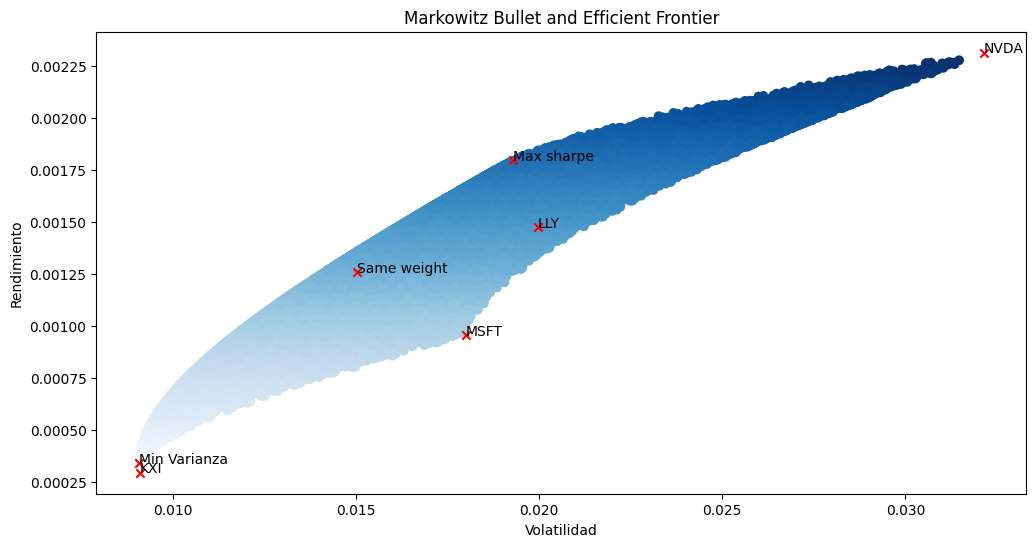

In [28]:
# Realizar grafica
plt.figure(figsize=(12, 6))

# Scatter plot de portafolios aleatorios
plt.scatter(vol_random, return_random, c = return_random, cmap="Blues")

# Scatter plot de Minima Varianza
plt.scatter(portfolio_min_var_vol_return, portfolio_min_var_mean_return, c = "red", marker="x")
plt.text(portfolio_min_var_vol_return, portfolio_min_var_mean_return, "Min Varianza")

# Scatter plot de Maximo de Sharpe
plt.scatter(portfolio_max_sharpe_vol_return, portfolio_max_sharpe_mean_return, c = "red", marker="x")
plt.text(portfolio_max_sharpe_vol_return, portfolio_max_sharpe_mean_return, "Max sharpe")

# Scatter plot de mismo pesos
plt.scatter(portfolio_same_weight_vol_return, portfolio_same_weight_mean_return, c = "red", marker="x")
plt.text(portfolio_same_weight_vol_return, portfolio_same_weight_mean_return, "Same weight")

# Nombrar eje x, y, titulo
plt.xlabel("Volatilidad")
plt.ylabel("Rendimiento")
plt.title("Markowitz Bullet and Efficient Frontier")
# Graficar coordenadas de activos individuales
mean_ind, vol_ind = returns.mean(), returns.std()

for i in range(len(returns.columns)):
    plt.scatter(vol_ind.iloc[i], mean_ind.iloc[i], c = "red", marker = "x")
    plt.text(vol_ind.iloc[i], mean_ind.iloc[i], returns.columns[i])

### Conclution

In [29]:
portfolios_metrics = pd.DataFrame({
    "mean" : [portfolio_min_var_mean_return, portfolio_max_sharpe_mean_return, portfolio_same_weight_mean_return],
    "vol" : [portfolio_min_var_vol_return, portfolio_max_sharpe_vol_return, portfolio_same_weight_vol_return]
},index=["min_var", "max_sharpe", "same_weight"])

portfolios_metrics["mean_annual"] = portfolios_metrics["mean"] * 252
portfolios_metrics["vol_annual"] = portfolios_metrics["vol"] * np.sqrt(252)
portfolios_metrics["cv"] = portfolios_metrics["vol_annual"] / portfolios_metrics["mean_annual"]
portfolios_metrics["sharpe"] = (portfolios_metrics["mean_annual"] - (rf / 252)) / portfolios_metrics["vol_annual"]

portfolios_metrics

,mean,vol,mean_annual,vol_annual,cv,sharpe
min_var,0.000341,0.009070,0.085815,0.143978,1.677776,0.596024
max_sharpe,0.001800,0.019300,0.453525,0.306385,0.675565,1.480241
same_weight,0.001261,0.015032,0.317800,0.238633,0.750890,1.331751


- ¿Cuál de estos portafolios es superior en términos de riesgo? Naturalmente si solo consideramos el riesgo el portafolio de minima varianza es el que ofrece la mejor metrica.

- ¿Cuál de estos portafolios es superior en términos de riesgo y retorno? En este sentido cuando incorporamos ambas metricas en un analisis el mejor portafolio es el de max sharpe, dado que si utilizamos el coeficiente de variacion para poder determinar la relacion entre riesgo y rendimiento de los portafolios podemos ver que quien ofrece mas unidades de rendimiento por unidad de riesgo es el de max sharpe, pues este en terminos anuales ofrece una unidad de rendimiento por cada 0.67 de riesgo que se toma.

- Interpreta la frontera eficiente con base en la teoría vista en clase y responde: ¿Qué pasa con el portafolio *equally weighted*?¿Es óptimo?¿Por qué? No, este no es optimo dado que no se encuentra en el frente de pareto o la frontera eficiente. Por tanto este portafolios nos estaría ofreciendo menos rendimiento del que podríamos obtener con una combinación optima asumiendo el mismo riesgo en la frontera eficiente.

- ¿Por qué un portafolio podría ser mejor que otro? ¿De qué depende que sea "mejor"? Si pensamos que somos inversionistas racionales, el mejor portafolio sera aquel que nos entrege un mejor rendimiento ajustado al riesgo, es decir, no solo queremos poco riesgo, sino también queremos que ese riesgo que tomamos pague un payoff de tal manera que valga la pena tomarlo. Sin embargo, dada la naturaleza de los procesos sociales, no todo depende de esta metrica, sino también de la adversión y toleracia al riesgo, por lo que también el mejor portafolio se puede ver como aquel que se ajusta mejor a nuestro cliente (metematicamente se podría describir como el portafolio que maximice la función de utilidad del individuo).

- Analiza las ponderaciones obtenidas por el método de mínima varianza y el de máximo de Sharpe para cada activo de manera individual, basándote en la descripción presentada en la primera sección de la tarea. ¿Qué factores explican que cada activo tenga una mayor o menor ponderación en uno de los métodos en comparación con el otro? 

In [42]:
w_min = dict(zip(returns.columns, result.x))
w_max = dict(zip(returns.columns, portfolio_weight_max_sharpe))

pd.DataFrame({
    "min_var" : w_min,
    "max_sharpe" : w_max
}).style.format("{:.6f}")

,min_var,max_sharpe
KXI,0.961974,0.000000
LLY,0.038026,0.615242
MSFT,0.000000,0.000000
NVDA,0.000000,0.384758


Lo que podemos apreciar es que los estadisticos que calculamos para cada activo influyen a la hora de determinar sus pesos para cada portafolio. 

En el caso del portafolio de minima varianza el activo con la mayor ponderación fue KXI el cual es el activo con la menor varianza de los 4, sin embargo también LLY ofrece una buena relación de rendimiento frente al riesgo, razón por la que a este se le asigno una parte del portafolio.

Por otro lado, en el portafolio de maximo de sharpe el activo que tiene la ponderación más grande es LLY este dado que como ya los habiamos mencionado cuenta con una excelente relación riesgo rendimiento. Asi mismo, se encuentra NVDA quien en el portafolio seguramente por su gran rendimiento se encuentre aportando buena parte del rendimiento esperado con la ponderación dada.

Por ultimo, si vemos MSFT en ninguno de los portafolios recibio una ponderación, seguramente esto es devido a una mala relación del riesgo y rendimiento, además que claramente se encuentra en un punto de la bullet de markowitz donde si el peso del portafolio fuera asignado totalmente a este activo ofreceria la peor relación de rendimiento para el nivel de riesgo dado.

- Concluye acerca de las ventajas y desventajas de una estrategia cuantitativa de asignación de activos frente a una basada en "feeling" o intuición.

Si solo hablamos de asset allocation entonces claramente existe una ventaja a la hora de establecer un proceso cuantitativo, ya que este otorga una estructura clara de la forma y metodologia de asignación de capital, que otorga diciplina, claridad y capacidad de auditoria en la toma de decisiones. Por otro lado, cuando uno asigna capital meramente por la intuición del inversionista, sus procesos estan más sujeto a factores externos y percepción del inversor, lo que puede ocasionar fallas o errores en la asignación lo que claramente puede influir en los costos de oportunidad de la compañía.